# 🏥 Patient Readmission — Exploratory Data Analysis

**Dataset**: Kaggle Diabetic Readmission · 101,766 encounters · 50 features

**Goal**: Understand distributions, missingness, class imbalance, and bivariate relationships before modelling.

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from src.data.loader import load_raw_data
from src.utils.config import (
    FIGURES_DIR, MEDICATION_COLS, DECEASED_DISPOSITION_IDS,
    AGE_MIDPOINT_MAP, TARGET_BINARY_MAP,
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    plt.savefig(FIGURES_DIR / name, bbox_inches="tight")
    print(f"Saved -> {FIGURES_DIR / name}")

print("Setup complete.")


Setup complete.


In [2]:
raw = load_raw_data(decode_ids=True)
print(f"Shape: {raw.shape}")
raw.head(3)


2026-03-28 15:50:33 | INFO     | src.data.loader | Loading raw data from /home/trupxl/Projects/patient-readmission/dataset_diabetes/diabetic_data.csv …
2026-03-28 15:50:34 | INFO     | src.data.loader | Loaded dataset — shape: (101766, 50)
2026-03-28 15:50:34 | INFO     | src.data.loader | Target distribution:
readmitted
NO     54864
>30    35545
<30    11357
2026-03-28 15:50:34 | INFO     | src.data.loader | Loaded ID mappings for: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
2026-03-28 15:50:34 | INFO     | src.data.loader | ID columns decoded with human-readable labels.
Shape: (101766, 53)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,admission_type_id_label,discharge_disposition_id_label,admission_source_id_label
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,NO,NULL,Not Mapped,Physician Referral
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,No,No,No,Ch,Yes,>30,Emergency,Discharged to home,Emergency Room
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,Yes,NO,Emergency,Discharged to home,Emergency Room


---
## 2.1 Missingness Analysis
The dataset uses `?` as a missing-value sentinel, which `load_raw_data()` already converts to `NaN`.

In [3]:
miss = raw.isnull().mean().mul(100).sort_values(ascending=False)
miss_nonzero = miss[miss > 0]
print("Columns with missing values:")
print(miss_nonzero.to_string())


Columns with missing values:
weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636


Saved -> /home/trupxl/Projects/patient-readmission/reports/figures/01_missingness.png


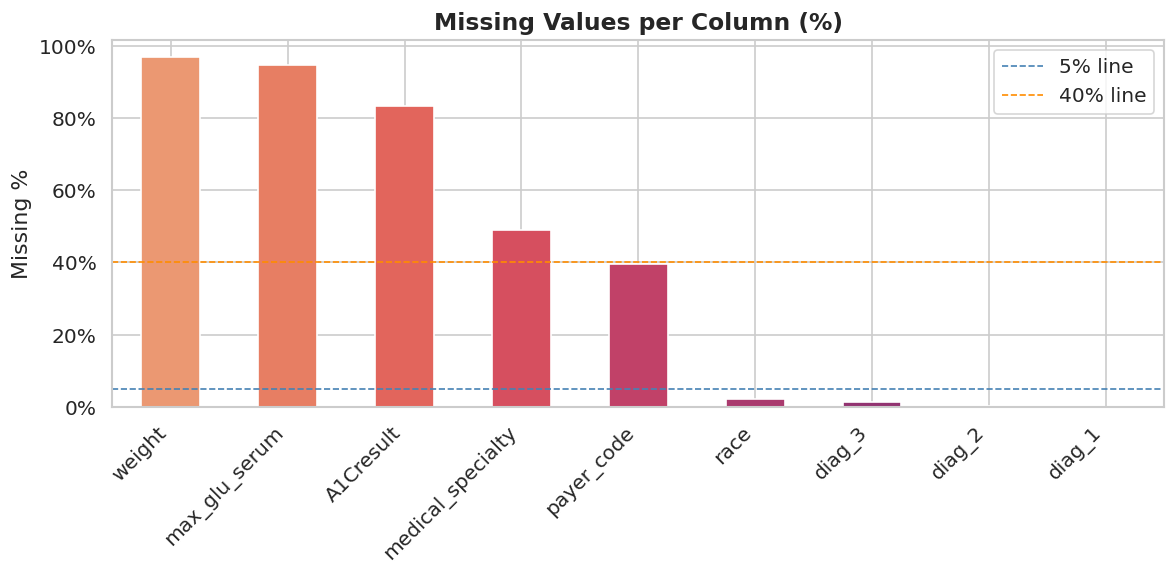

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
miss_nonzero.plot(kind="bar", color=sns.color_palette("flare", len(miss_nonzero)), ax=ax)
ax.set_title("Missing Values per Column (%)", fontsize=14, fontweight="bold")
ax.set_ylabel("Missing %")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.axhline(5, color="steelblue", ls="--", lw=1, label="5% line")
ax.axhline(40, color="darkorange", ls="--", lw=1, label="40% line")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
savefig("01_missingness.png")
plt.show()


| Column | Missing % | Strategy |
|---|---|---|
| `weight` | ~97% | **Drop** — too sparse to impute |
| `medical_specialty` | ~49% | Keep as `Unknown` + group rare into `Other` |
| `payer_code` | ~40% | **Drop** — low signal + near half missing |
| `race` | ~2% | Impute as `Unknown` |
| `diag_1/2/3` | ~1-2% | Impute as `Missing` category |
| `max_glu_serum` / `A1Cresult` | `None` literal | Keep — `None` = "not tested" is **clinically informative** |

---
## 2.2 Target Variable Analysis

The target `readmitted` has three classes: `NO`, `>30`, `<30`.
We binarize to the clinically relevant question: **was the patient readmitted within 30 days?**

Saved -> /home/trupxl/Projects/patient-readmission/reports/figures/02_target_distribution.png


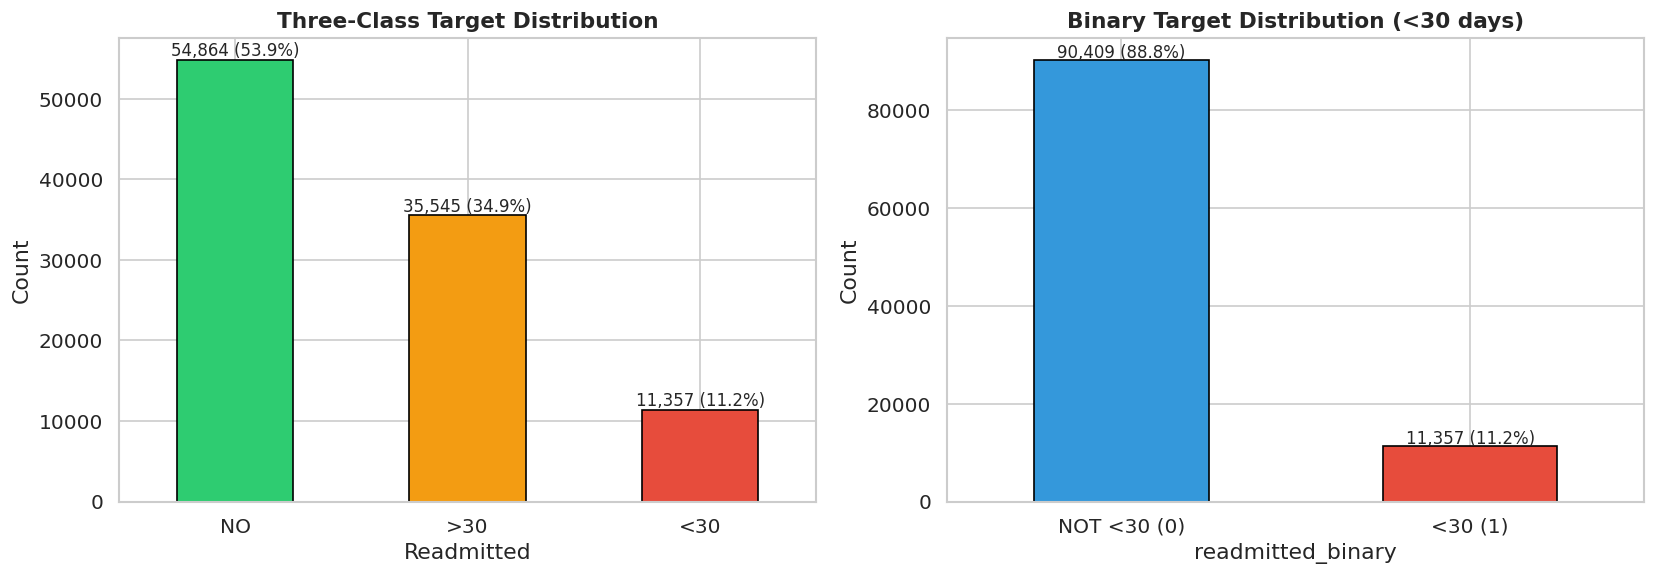


Imbalance ratio (neg:pos): 8.0:1
Positive class rate: 11.2%


In [6]:
# ── Three-class + binarized distribution ──
target_counts = raw["readmitted"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors3 = ["#2ecc71", "#f39c12", "#e74c3c"]
target_counts.plot(kind="bar", ax=axes[0], color=colors3, edgecolor="black")
axes[0].set_title("Three-Class Target Distribution", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("Readmitted")
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 500, f"{v:,} ({v/len(raw)*100:.1f}%)", ha="center", fontsize=10)
axes[0].tick_params(axis="x", rotation=0)

raw["readmitted_binary"] = raw["readmitted"].map(TARGET_BINARY_MAP)
binary_counts = raw["readmitted_binary"].value_counts().sort_index()

colors2 = ["#3498db", "#e74c3c"]
binary_counts.plot(kind="bar", ax=axes[1], color=colors2, edgecolor="black")
axes[1].set_title("Binary Target Distribution (<30 days)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(["NOT <30 (0)", "<30 (1)"], rotation=0)
for i, v in enumerate(binary_counts):
    axes[1].text(i, v + 500, f"{v:,} ({v/len(raw)*100:.1f}%)", ha="center", fontsize=10)

plt.tight_layout()
savefig("02_target_distribution.png")
plt.show()

imb_ratio = binary_counts[0] / binary_counts[1]
print(f"\nImbalance ratio (neg:pos): {imb_ratio:.1f}:1")
print(f"Positive class rate: {binary_counts[1]/len(raw)*100:.1f}%")


Saved -> /home/trupxl/Projects/patient-readmission/reports/figures/03_readmit_by_demographics.png


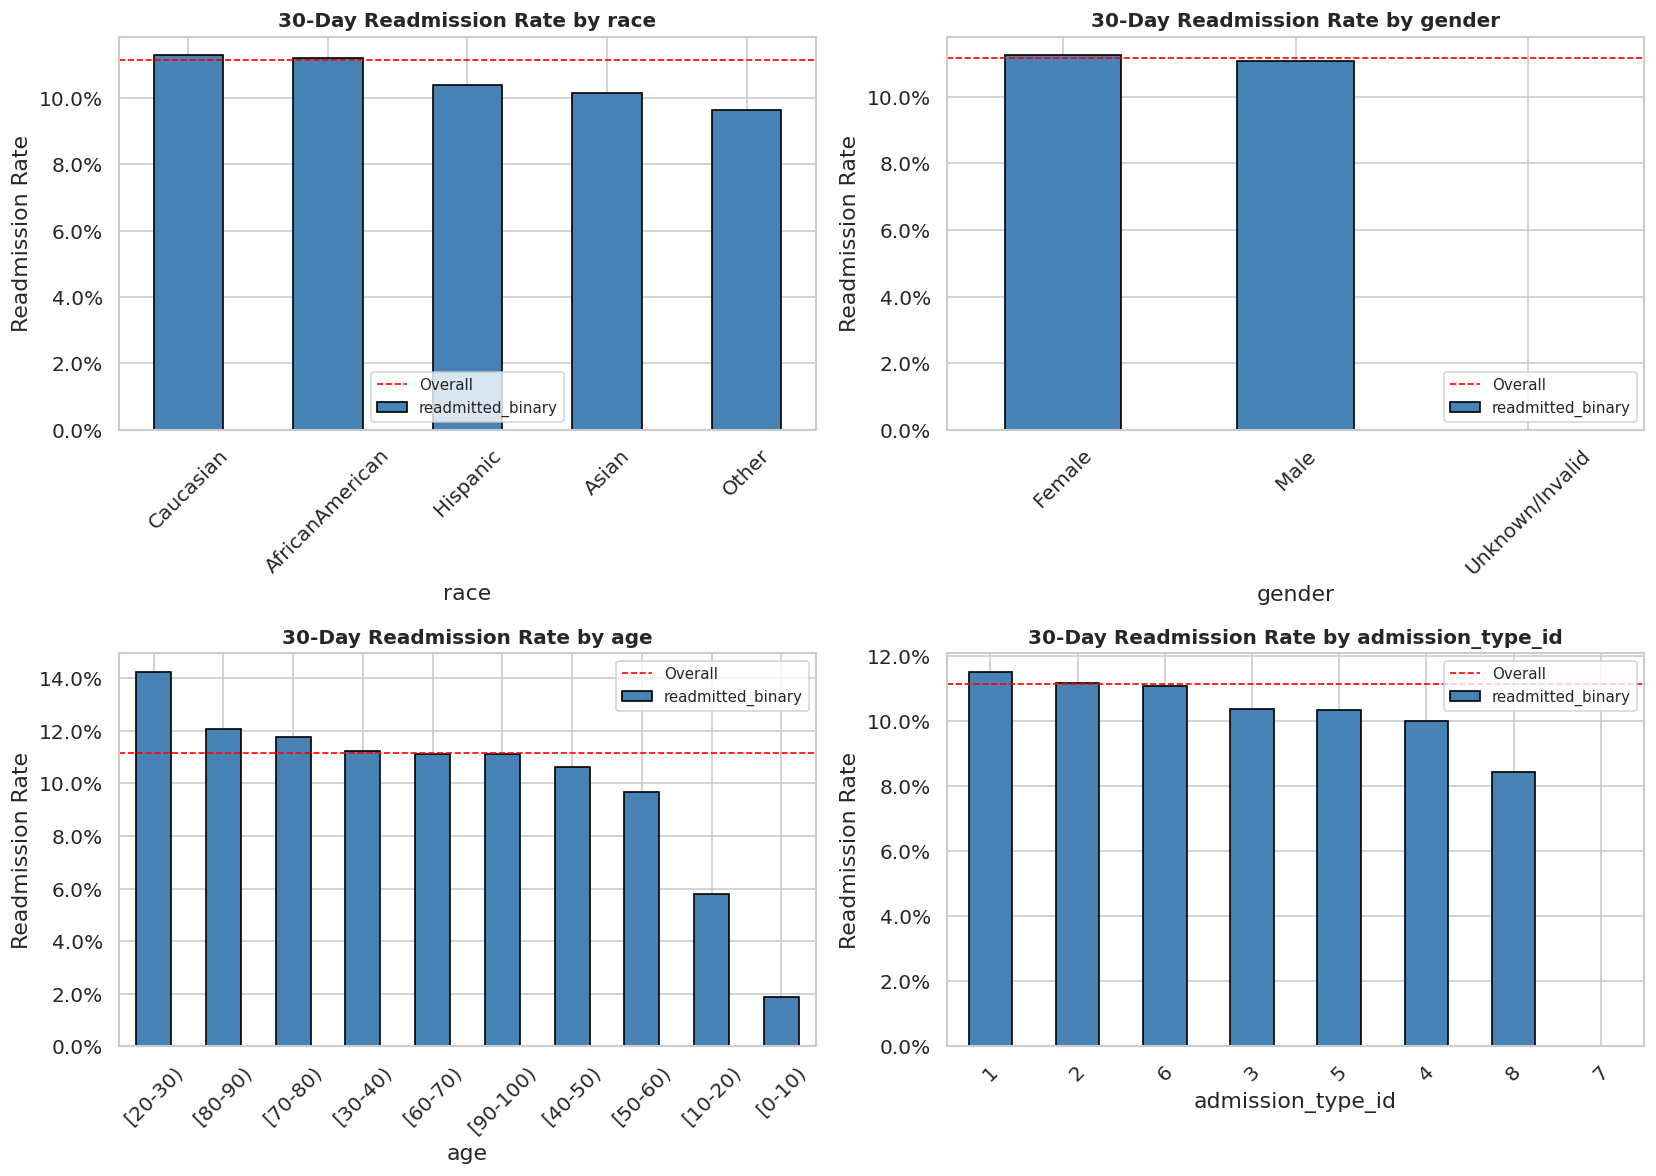

In [7]:
# ── Readmission rates by demographic groups ──
def readmit_rate(df, col, target="readmitted_binary"):
    return df.groupby(col)[target].mean().sort_values(ascending=False)

demo_cols = ["race", "gender", "age", "admission_type_id"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.ravel(), demo_cols):
    rates = readmit_rate(raw, col)
    rates.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
    ax.set_title(f"30-Day Readmission Rate by {col}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Readmission Rate")
    ax.axhline(raw["readmitted_binary"].mean(), ls="--", color="red", lw=1, label="Overall")
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=45)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
savefig("03_readmit_by_demographics.png")
plt.show()


**Key Findings (Target Variable)**

- Three-class split: NO ~ 54%, >30 ~ 35%, <30 ~ 11%
- Binary task imbalance: ~1:8 (positive class ~ 11.2%)
- Readmission rates vary by race, age; older patients show higher rates
- Emergency admissions have higher readmission rates than elective

---
## 2.3 Feature Distributions

Examine numeric feature histograms, categorical value counts, medication patterns, and top ICD codes.

Saved -> /home/trupxl/Projects/patient-readmission/reports/figures/04_numeric_distributions.png


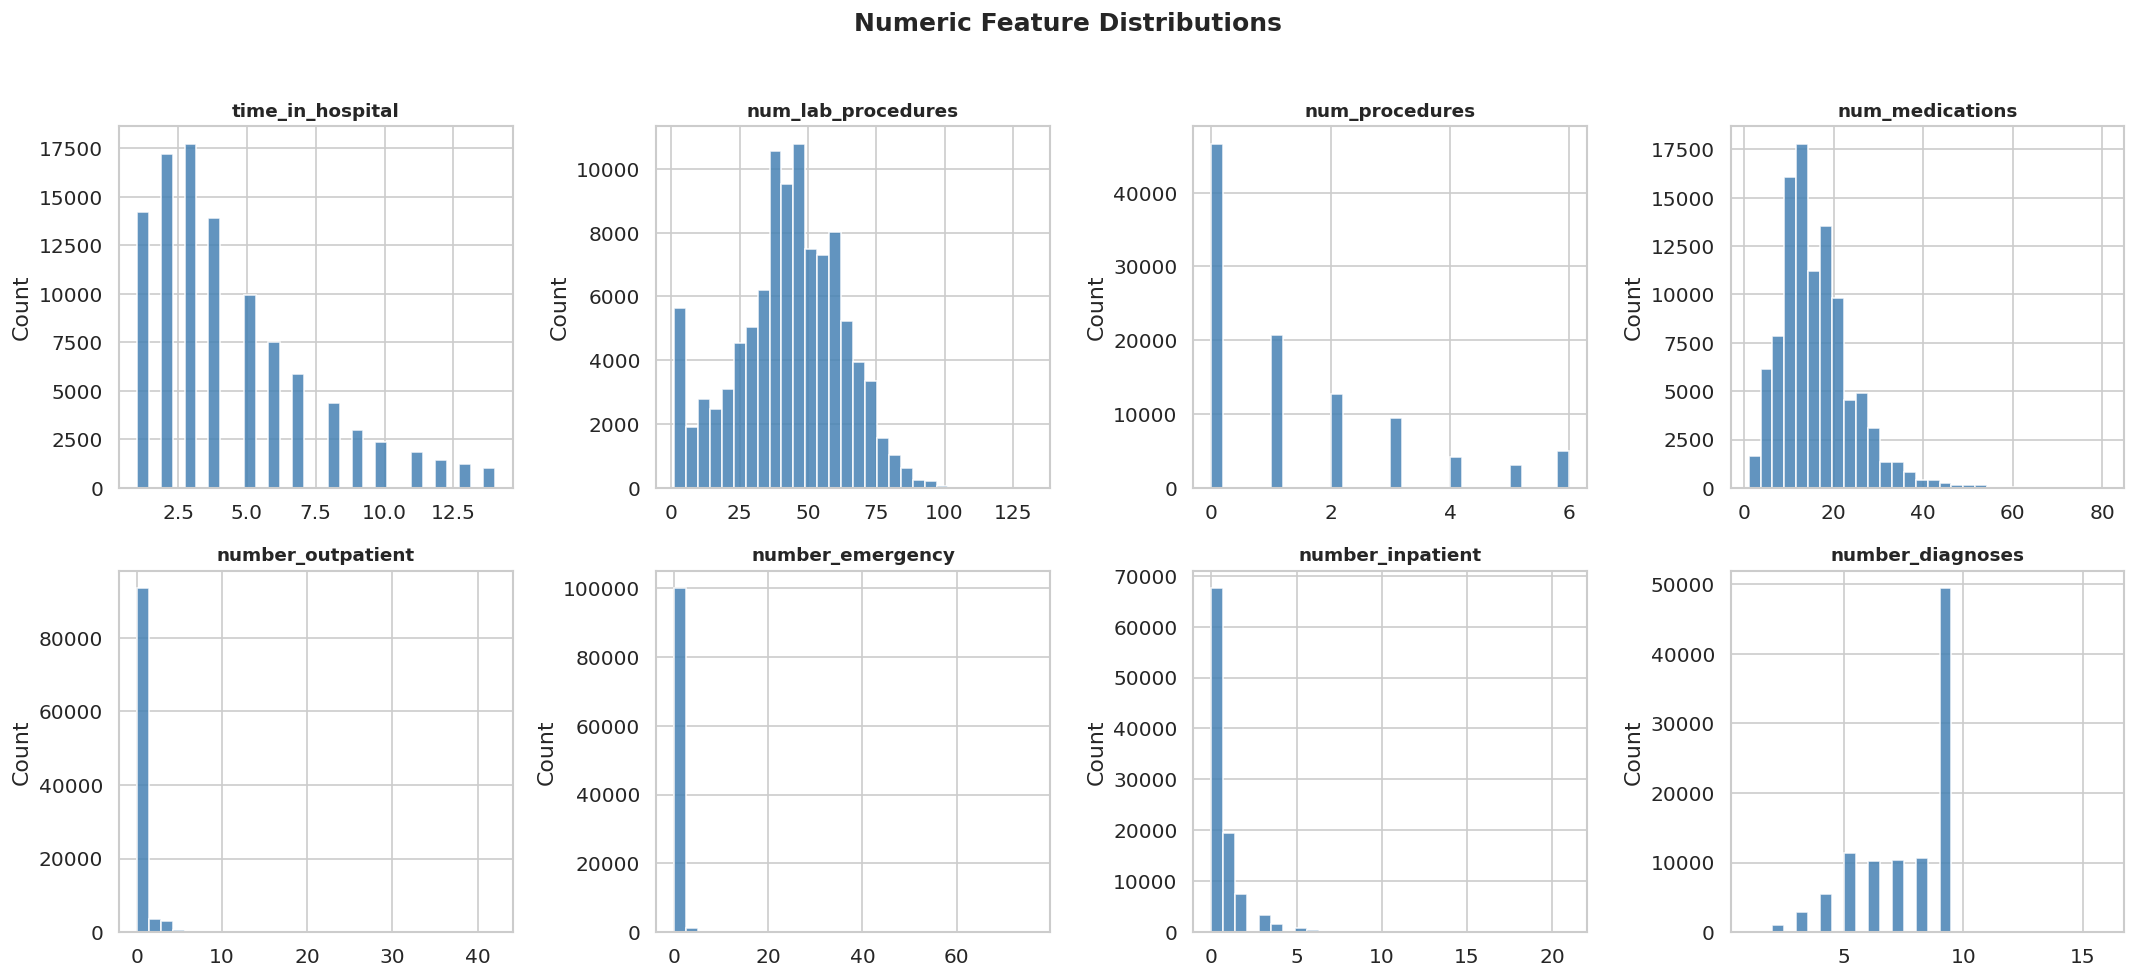

In [8]:
# ── Numeric feature histograms ──
numeric_cols = [
    "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), numeric_cols):
    raw[col].hist(bins=30, ax=ax, color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_ylabel("Count")

plt.suptitle("Numeric Feature Distributions", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
savefig("04_numeric_distributions.png")
plt.show()


Saved -> /home/trupxl/Projects/patient-readmission/reports/figures/05_categorical_distributions.png


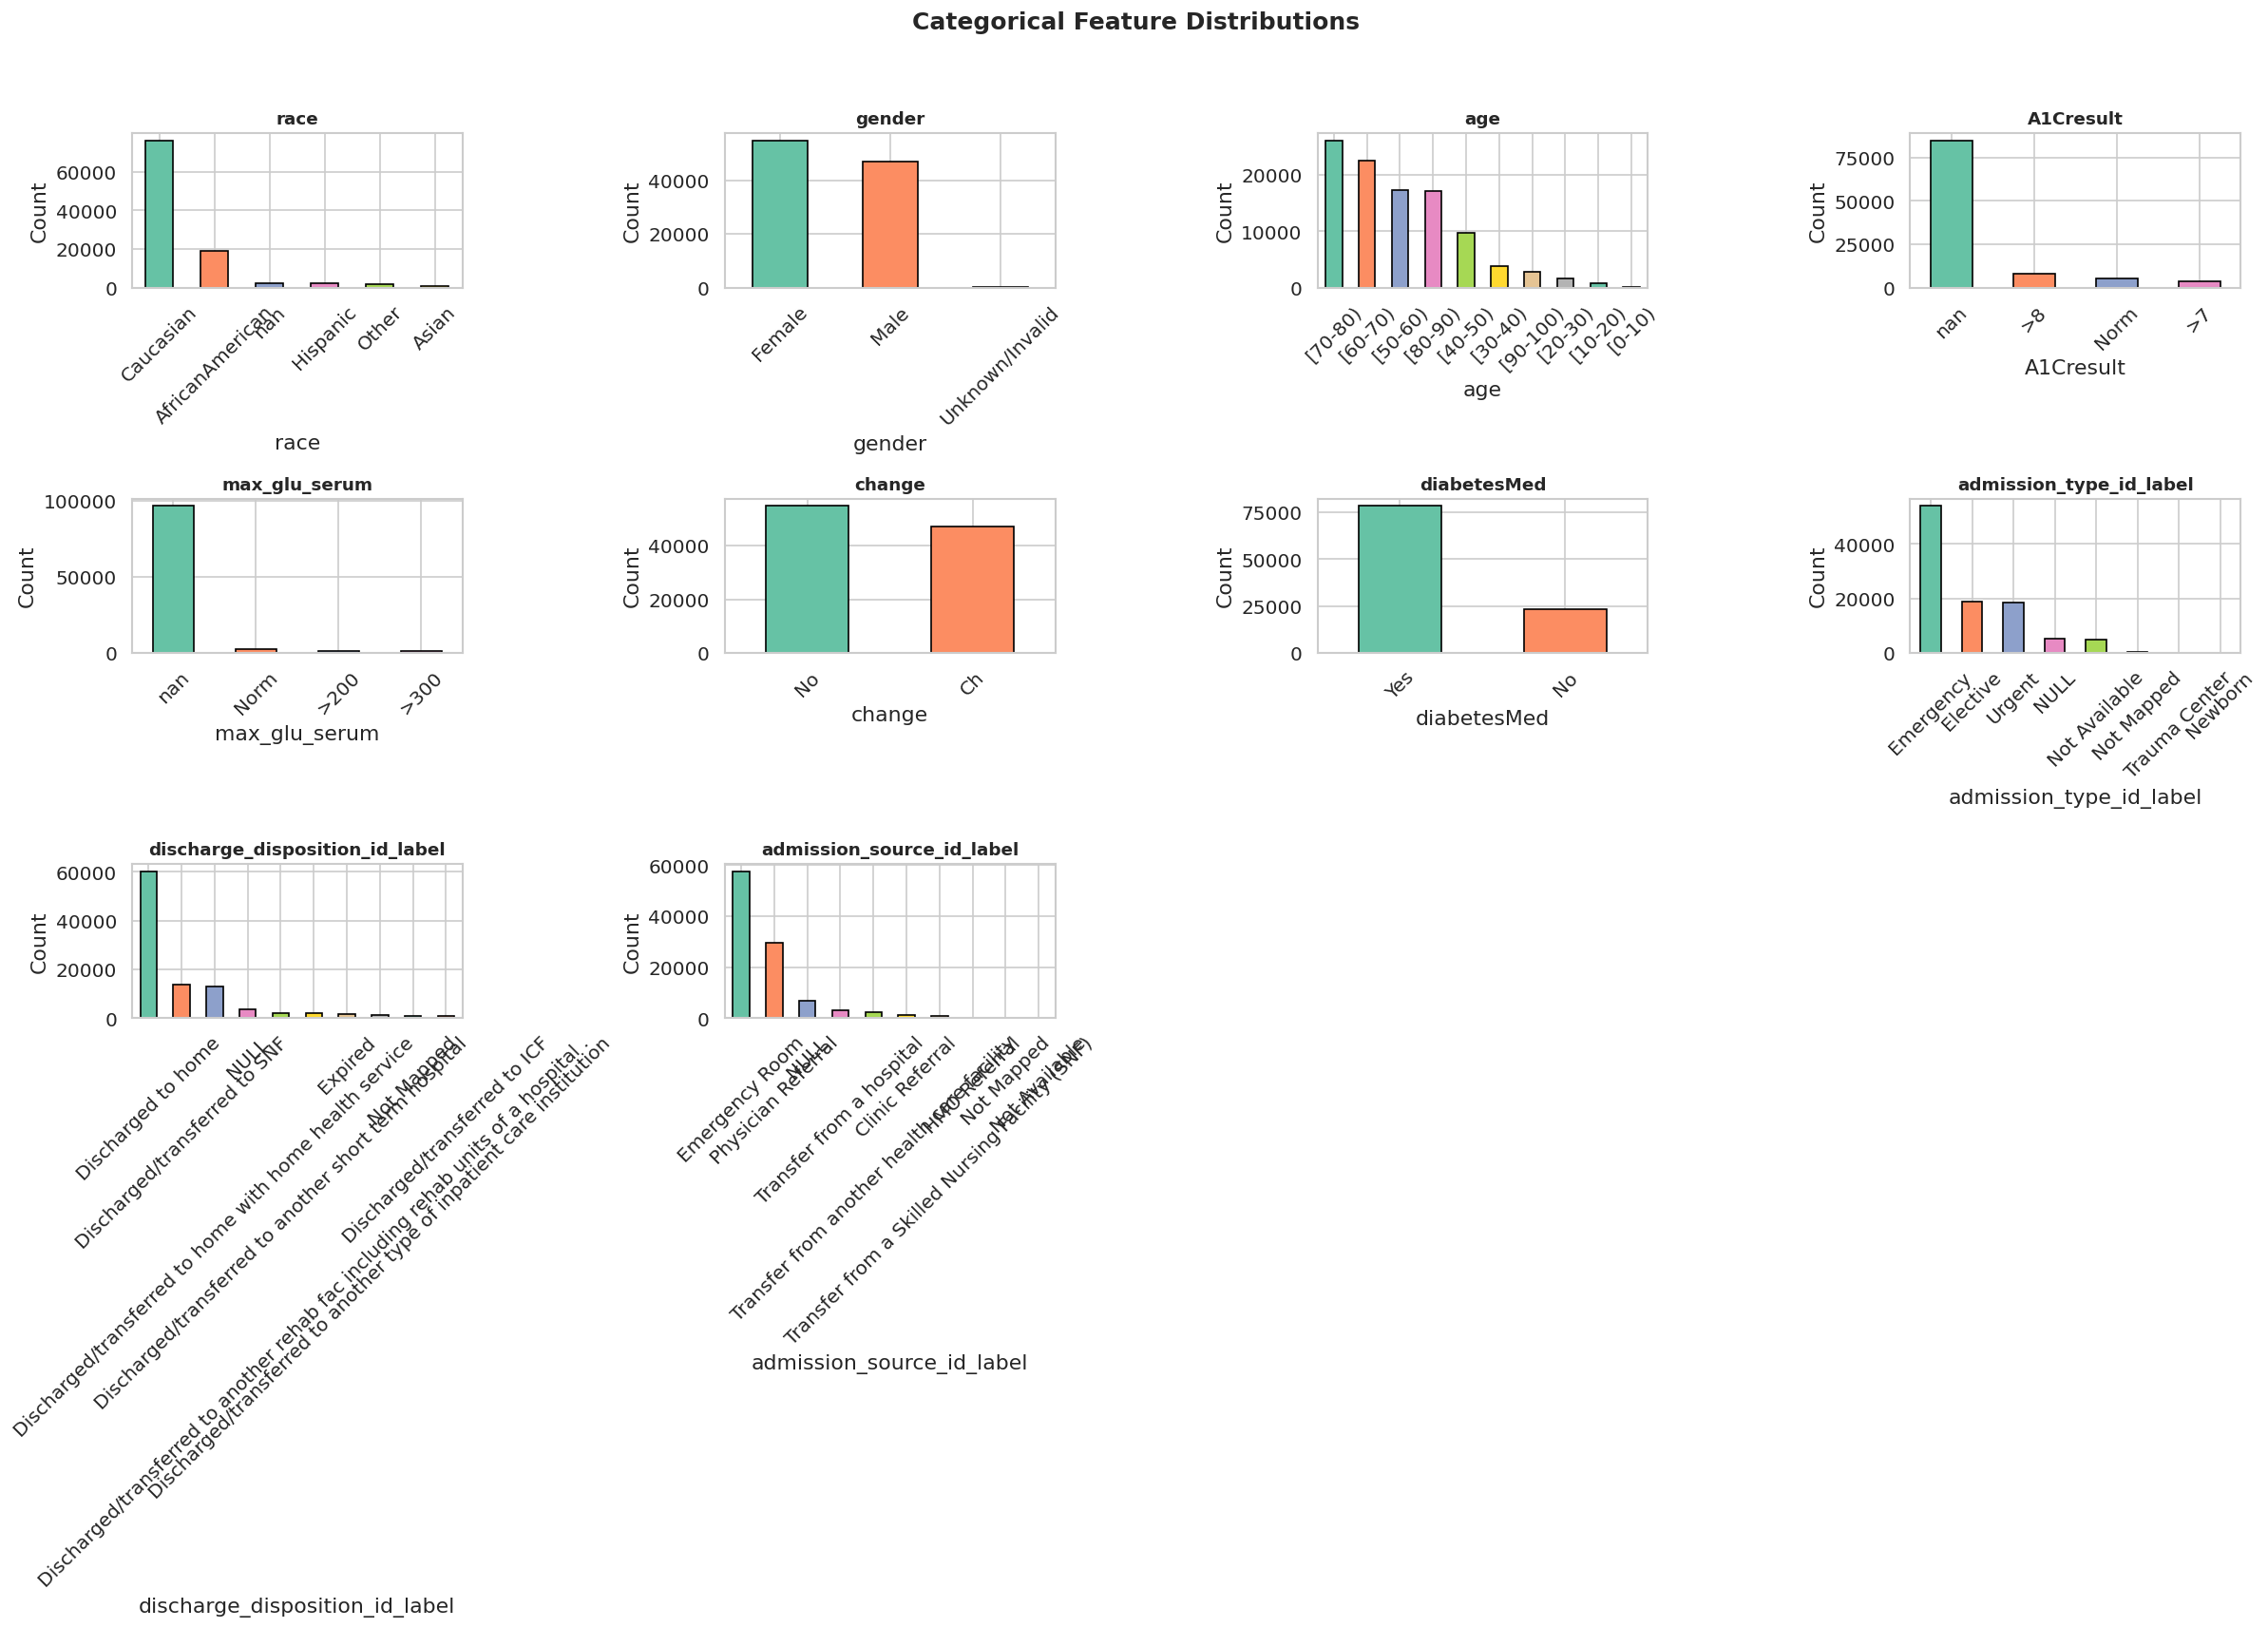

In [9]:
# ── Categorical feature value counts ──
cat_cols = [
    "race", "gender", "age",
    "A1Cresult", "max_glu_serum",
    "change", "diabetesMed",
    "admission_type_id_label", "discharge_disposition_id_label", "admission_source_id_label"
]

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes_flat = axes.ravel()

for i, col in enumerate(cat_cols):
    if col in raw.columns:
        vc = raw[col].value_counts(dropna=False).head(10) # limit to top 10 for readability
        vc.plot(kind="bar", ax=axes_flat[i], color=sns.color_palette("Set2", len(vc)), edgecolor="black")
        axes_flat[i].set_title(col, fontsize=11, fontweight="bold")
        axes_flat[i].set_ylabel("Count")
        axes_flat[i].tick_params(axis="x", rotation=45)

# Hide unused axes
for j in range(len(cat_cols), len(axes_flat)):
    axes_flat[j].axis("off")
plt.suptitle("Categorical Feature Distributions", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
savefig("05_categorical_distributions.png")
plt.show()


Saved -> /home/trupxl/Projects/patient-readmission/reports/figures/06_medication_patterns.png


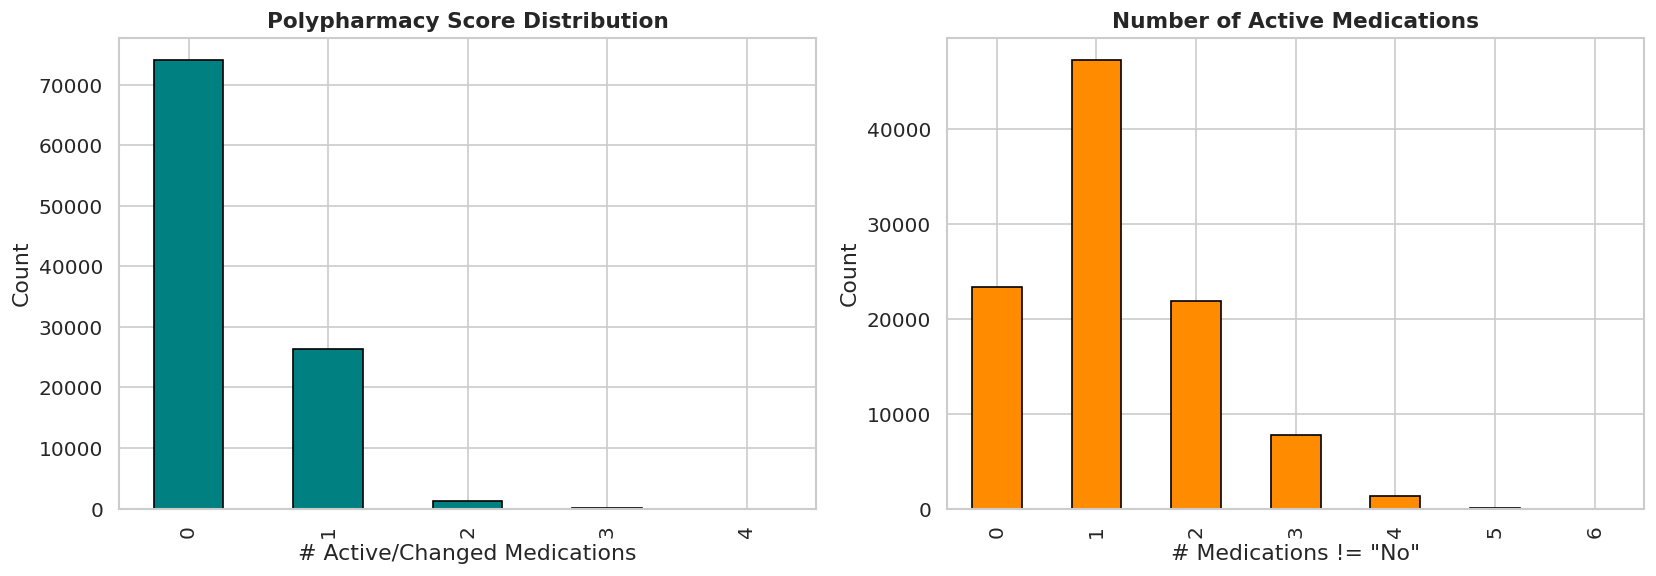

In [9]:
# ── Polypharmacy score + active medication count ──
med_df = raw[MEDICATION_COLS]
poly_score = med_df.apply(lambda row: sum(v not in ("No", "Steady") for v in row), axis=1)
raw["_poly_score"] = poly_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

poly_score.value_counts().sort_index().plot(kind="bar", ax=axes[0],
    color="teal", edgecolor="black")
axes[0].set_title("Polypharmacy Score Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("# Active/Changed Medications")
axes[0].set_ylabel("Count")

active_count = med_df.apply(lambda row: sum(v != "No" for v in row), axis=1)
raw["_active_meds"] = active_count
active_count.value_counts().sort_index().plot(kind="bar", ax=axes[1],
    color="darkorange", edgecolor="black")
axes[1].set_title("Number of Active Medications", fontsize=13, fontweight="bold")
axes[1].set_xlabel("# Medications != \"No\"")
axes[1].set_ylabel("Count")

plt.tight_layout()
savefig("06_medication_patterns.png")
plt.show()


Saved -> /home/trupxl/Projects/patient-readmission/reports/figures/07_top20_diag1_codes.png


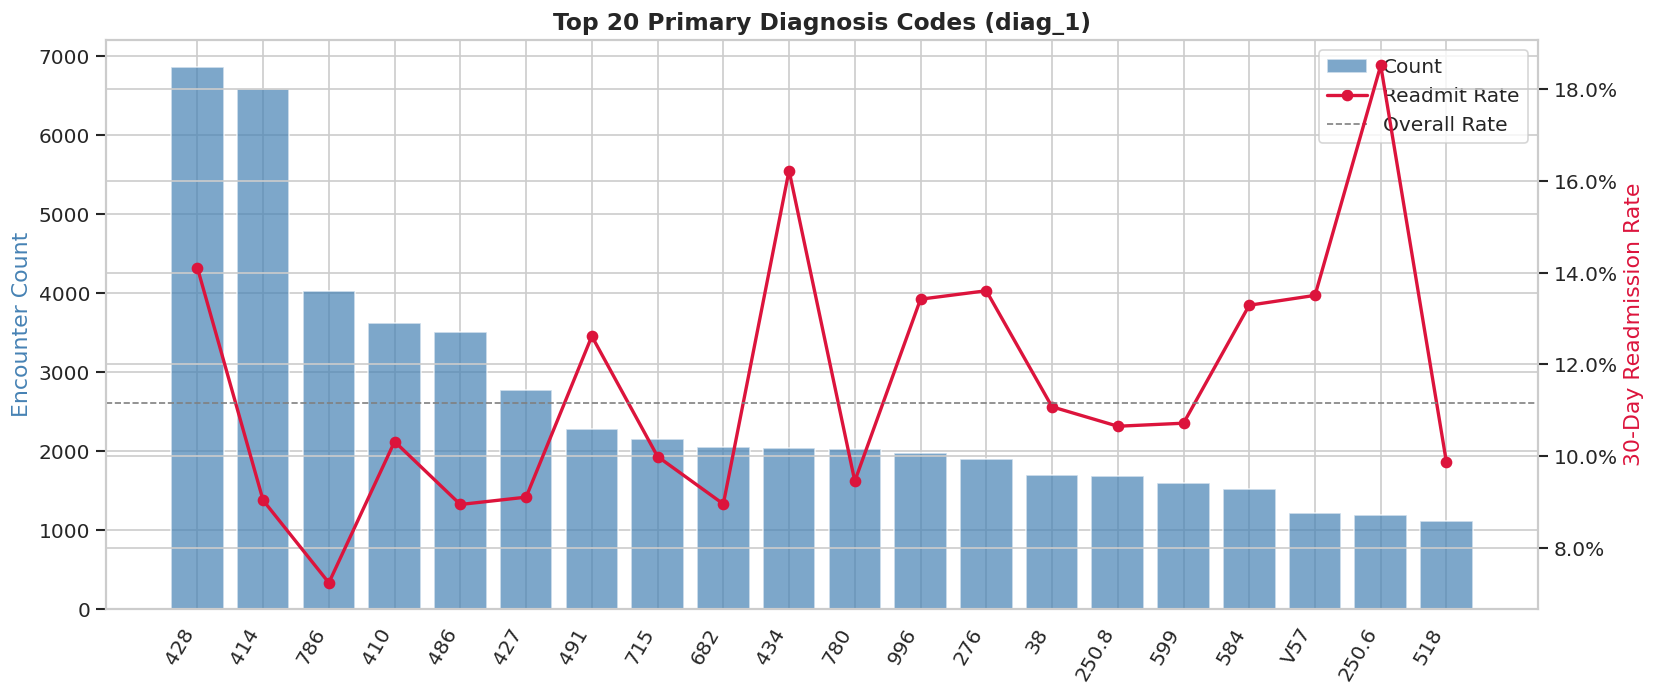

        readmit_rate  count
diag_1                     
428         0.141067   6862
414         0.090412   6581
786         0.072460   4016
410         0.103210   3614
486         0.089510   3508
427         0.091106   2766
491         0.126154   2275
715         0.099954   2151
682         0.089618   2042
434         0.162229   2028
780         0.094601   2019
996         0.134215   1967
276         0.136051   1889
38          0.110782   1688
250.8       0.106548   1680
599         0.107210   1595
584         0.132895   1520
V57         0.135046   1207
250.6       0.185123   1183
518         0.098655   1115


In [10]:
# ── Top-20 primary diagnosis codes and readmission rates ──
top20_diag = raw["diag_1"].value_counts().head(20)
diag1_readmit = (
    raw[raw["diag_1"].isin(top20_diag.index)]
    .groupby("diag_1")["readmitted_binary"]
    .agg(["mean", "count"])
    .sort_values("count", ascending=False)
)
diag1_readmit.columns = ["readmit_rate", "count"]

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

x = range(len(diag1_readmit))
ax1.bar(x, diag1_readmit["count"], color="steelblue", alpha=0.7, label="Count")
ax2.plot(x, diag1_readmit["readmit_rate"], "o-", color="crimson", lw=2, label="Readmit Rate")

ax1.set_xticks(list(x))
ax1.set_xticklabels(diag1_readmit.index, rotation=60, ha="right")
ax1.set_ylabel("Encounter Count", color="steelblue")
ax2.set_ylabel("30-Day Readmission Rate", color="crimson")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.axhline(raw["readmitted_binary"].mean(), ls="--", color="gray", lw=1, label="Overall Rate")

ax1.set_title("Top 20 Primary Diagnosis Codes (diag_1)", fontsize=14, fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
savefig("07_top20_diag1_codes.png")
plt.show()
print(diag1_readmit.to_string())


**Key Findings (Feature Distributions)**

- **Numeric**: `number_outpatient`, `number_emergency`, `number_inpatient` are heavily right-skewed (most = 0).
- **Categorical**: Age peaks at 70-80; majority Caucasian; most have `diabetesMed=Yes`.
- **Medications**: Most encounters have 0 active/changed meds. Insulin is the most commonly prescribed.
- **ICD-9**: Diabetes codes (250.xx) dominate; readmission rates vary across diagnosis groups.

---
## 2.4 Correlation & Bivariate Analysis

Explore pairwise relationships among numeric features and readmission rates by key clinical variables.

Saved -> /home/trupxl/Projects/patient-readmission/reports/figures/08_correlation_heatmap.png


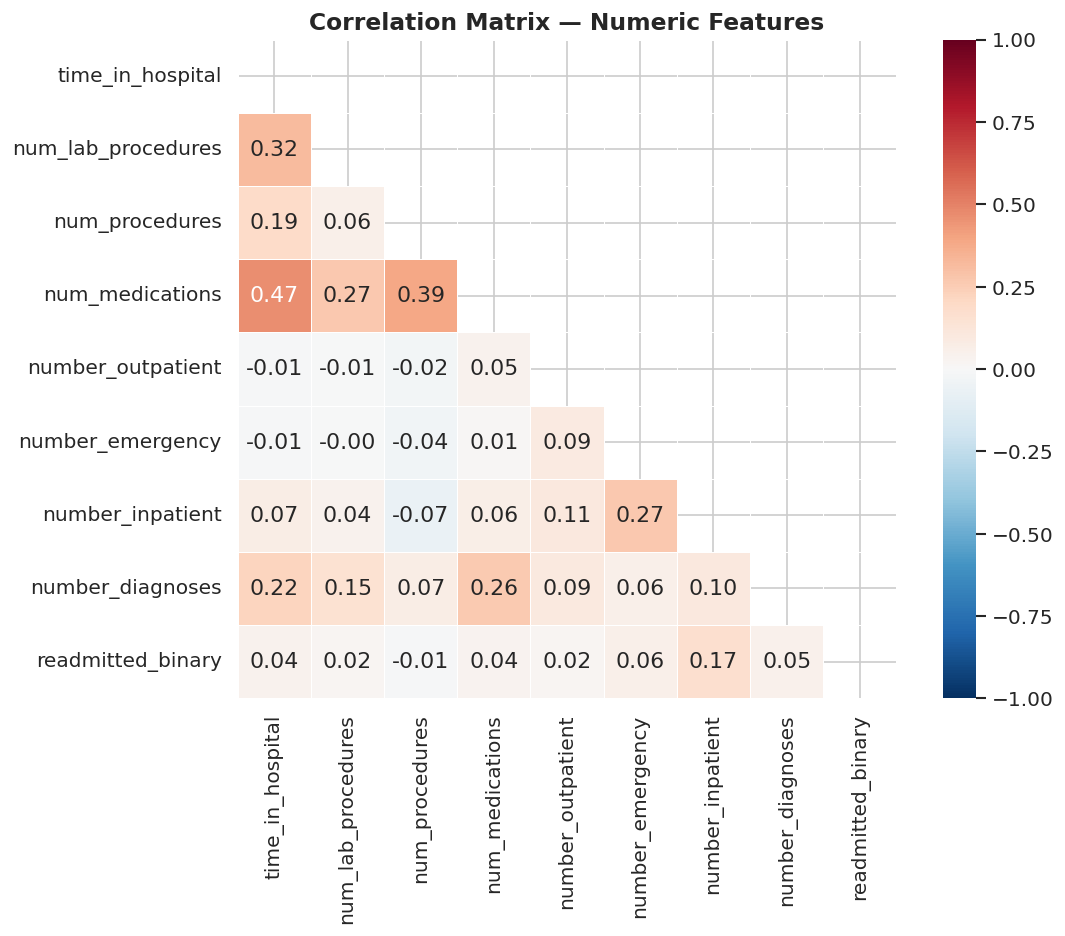

In [10]:
# ── Correlation heatmap ──
numeric_for_corr = [
    "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses", "readmitted_binary",
]

corr = raw[numeric_for_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
savefig("08_correlation_heatmap.png")
plt.show()


Saved -> /home/trupxl/Projects/patient-readmission/reports/figures/09_readmit_by_discharge.png


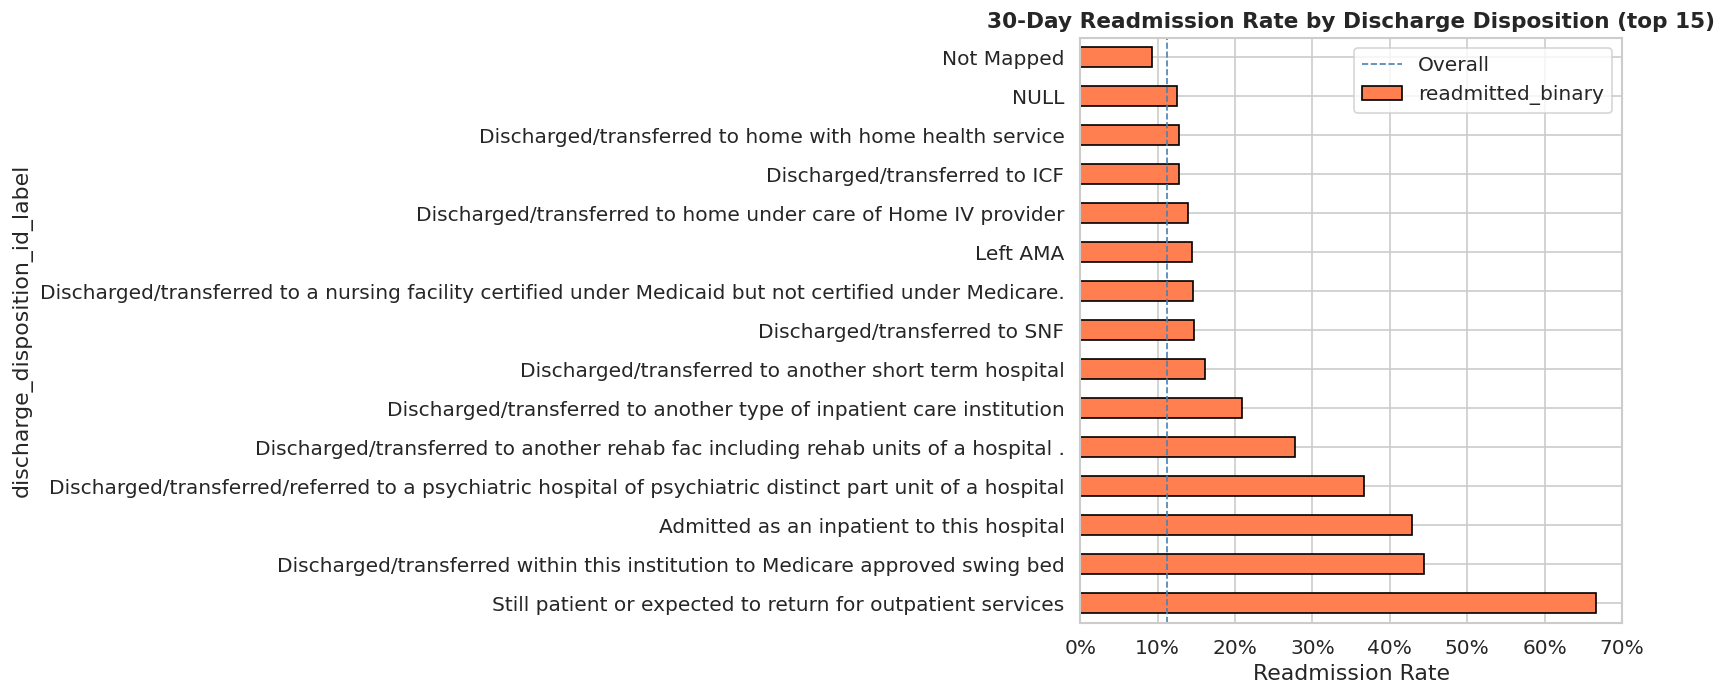

In [11]:
# ── Readmission rate by discharge disposition ──
disp_col = "discharge_disposition_id_label" if "discharge_disposition_id_label" in raw.columns else "discharge_disposition_id"

disp_rate = readmit_rate(raw, disp_col)

fig, ax = plt.subplots(figsize=(14, 6))
disp_rate.head(15).plot(kind="barh", ax=ax, color="coral", edgecolor="black")
ax.set_title("30-Day Readmission Rate by Discharge Disposition (top 15)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Readmission Rate")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.axvline(raw["readmitted_binary"].mean(), ls="--", color="steelblue", lw=1, label="Overall")
ax.legend()
plt.tight_layout()
savefig("09_readmit_by_discharge.png")
plt.show()


Saved -> /home/trupxl/Projects/patient-readmission/reports/figures/10_readmit_by_inpatient.png


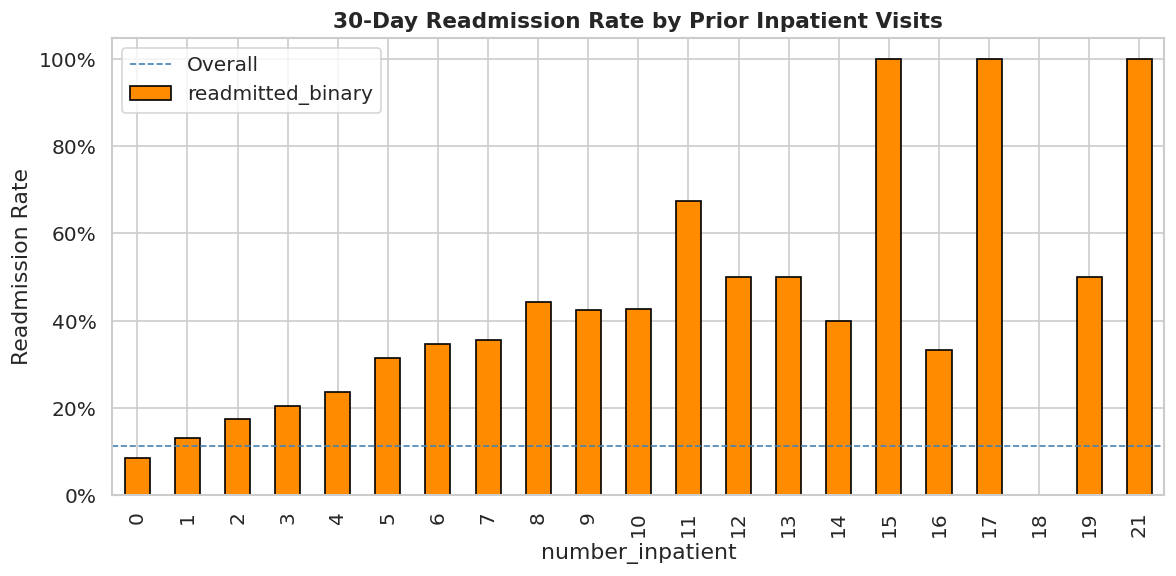

Prior inpatient visits is one of the strongest signals for readmission.


In [13]:
# ── Readmission rate by prior inpatient visits ──
inp_rate = readmit_rate(raw, "number_inpatient")

fig, ax = plt.subplots(figsize=(10, 5))
inp_rate.sort_index().plot(kind="bar", ax=ax, color="darkorange", edgecolor="black")
ax.set_title("30-Day Readmission Rate by Prior Inpatient Visits",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Readmission Rate")
ax.set_xlabel("number_inpatient")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.axhline(raw["readmitted_binary"].mean(), ls="--", color="steelblue", lw=1, label="Overall")
ax.legend()
plt.tight_layout()
savefig("10_readmit_by_inpatient.png")
plt.show()
print("Prior inpatient visits is one of the strongest signals for readmission.")


Saved -> /home/trupxl/Projects/patient-readmission/reports/figures/11_readmit_by_age.png


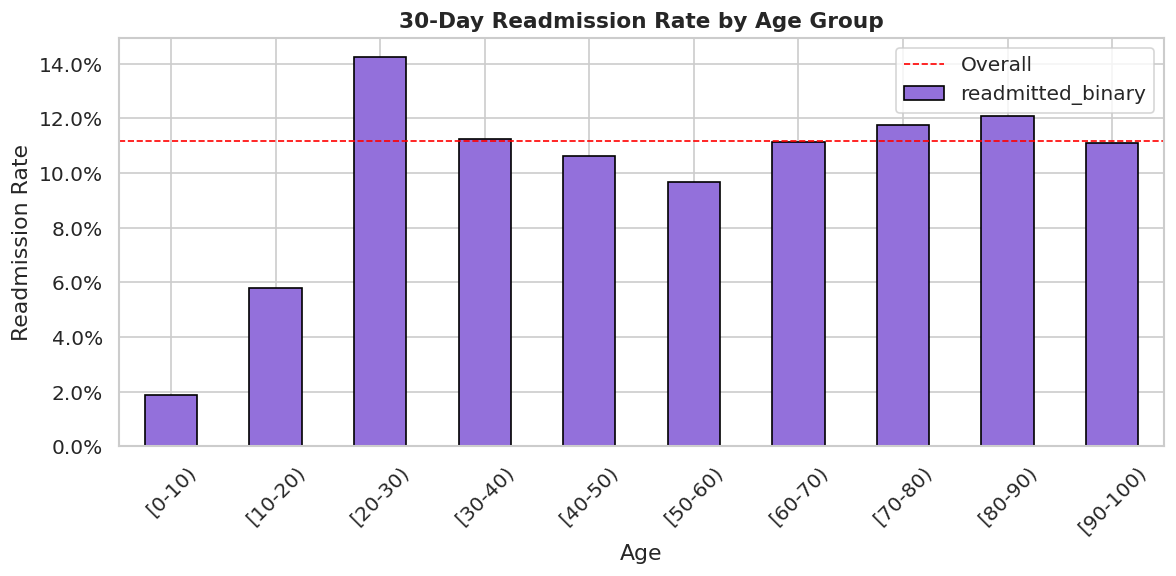

In [14]:
# ── Readmission rate by age group ──
age_rate = readmit_rate(raw, "age")
age_order = sorted(age_rate.index, key=lambda x: int(x.strip("[").split("-")[0]))
age_rate = age_rate.reindex(age_order)

fig, ax = plt.subplots(figsize=(10, 5))
age_rate.plot(kind="bar", ax=ax, color="mediumpurple", edgecolor="black")
ax.set_title("30-Day Readmission Rate by Age Group", fontsize=13, fontweight="bold")
ax.set_ylabel("Readmission Rate")
ax.set_xlabel("Age")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.axhline(raw["readmitted_binary"].mean(), ls="--", color="red", lw=1, label="Overall")
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
savefig("11_readmit_by_age.png")
plt.show()


Saved -> /home/trupxl/Projects/patient-readmission/reports/figures/12_readmit_by_a1c.png


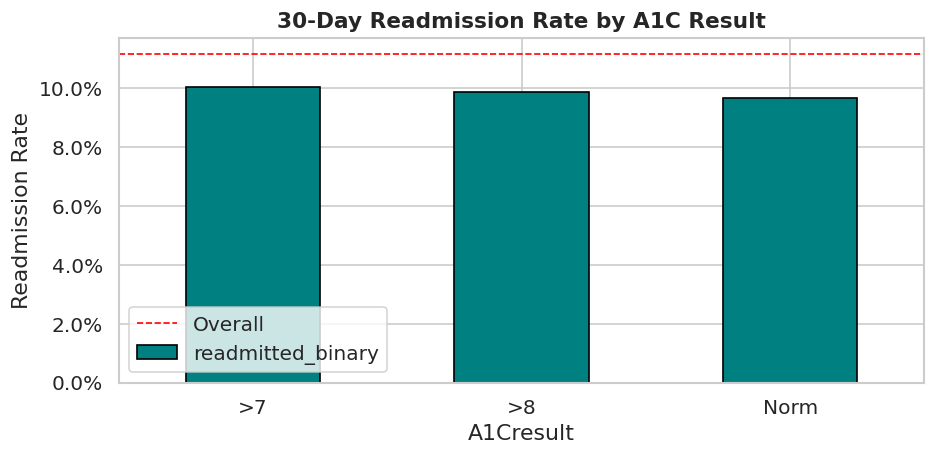

In [15]:
# ── Readmission rate by A1C result ──
a1c_rate = readmit_rate(raw, "A1Cresult")

fig, ax = plt.subplots(figsize=(8, 4))
a1c_rate.plot(kind="bar", ax=ax, color="teal", edgecolor="black")
ax.set_title("30-Day Readmission Rate by A1C Result", fontsize=13, fontweight="bold")
ax.set_ylabel("Readmission Rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.axhline(raw["readmitted_binary"].mean(), ls="--", color="red", lw=1, label="Overall")
ax.legend()
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
savefig("12_readmit_by_a1c.png")
plt.show()


In [16]:
# ── Data leakage: expired/hospice patients ──
deceased = raw[raw["discharge_disposition_id"].isin(DECEASED_DISPOSITION_IDS)]
n_deceased = len(deceased)
pct_deceased = n_deceased / len(raw) * 100
readmit_in_deceased = deceased["readmitted_binary"].sum()

print(f"Encounters with expired/hospice discharge: {n_deceased:,} ({pct_deceased:.1f}%)")
print(f"Of those, readmitted <30 days: {readmit_in_deceased} (expected ~ 0)")
print(f"Disposition IDs flagged: {sorted(DECEASED_DISPOSITION_IDS)}")
print()
print("These patients CANNOT be readmitted. Keeping them creates label leakage.")
print("They will be removed in cleaner.py.")


Encounters with expired/hospice discharge: 2,423 (2.4%)
Of those, readmitted <30 days: 43 (expected ~ 0)
Disposition IDs flagged: [11, 13, 14, 19, 20, 21]

These patients CANNOT be readmitted. Keeping them creates label leakage.
They will be removed in cleaner.py.


**Key Findings (Bivariate Analysis)**

- **Correlation**: `num_medications` and `time_in_hospital` moderately correlated (~0.4). Most numeric features have low individual target correlation.
- **Discharge disposition**: SNF/home health dispositions have higher readmission rates than home.
- **Prior inpatient visits**: **Strongest univariate signal** — rate nearly doubles with 2+ prior visits.
- **Age**: Readmission rate peaks at 60-80, slightly decreasing after (survival bias / hospice).
- **A1C result**: Patients with A1C >8 show slightly elevated readmission vs not tested.
- **Data leakage**: ~3% of encounters are deaths/hospice — will be **removed**.

---
## 2.5 Duplicate Patient Analysis

The dataset has multiple encounters per patient. To prevent data leakage between train/test,
we must decide how to handle multi-encounter patients.

Total encounters:      101,766
Unique patients:        71,518
Duplicate encounters:   30,248 (29.7%)

Encounters per patient stats:
count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000



Saved -> /home/trupxl/Projects/patient-readmission/reports/figures/13_encounters_per_patient.png


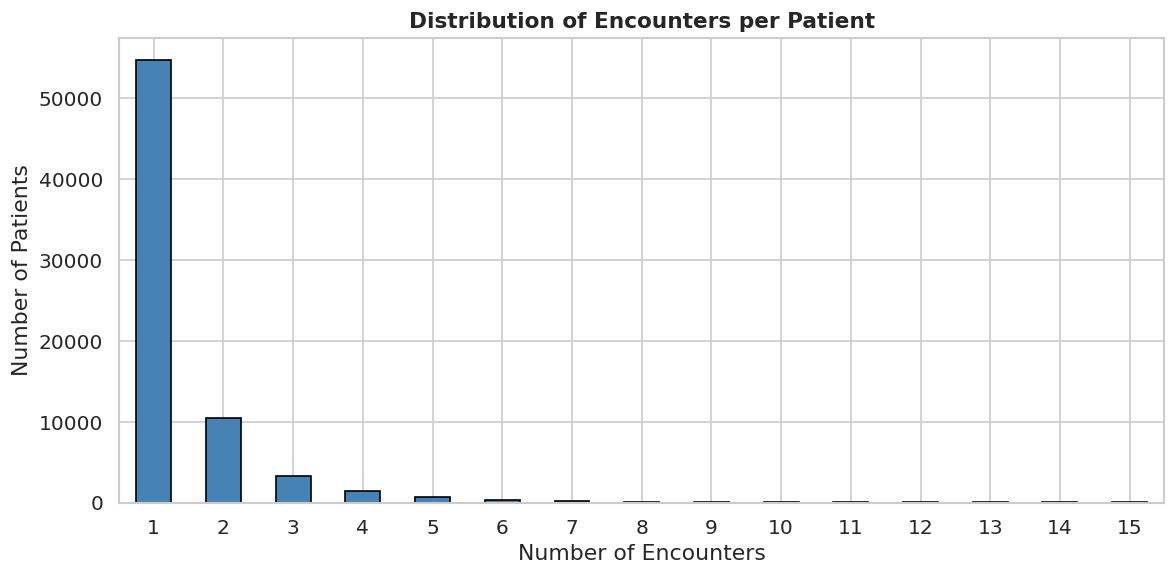

In [17]:
# ── Unique patients vs total encounters ──
n_encounters = len(raw)
n_unique_patients = raw["patient_nbr"].nunique()
n_dup = n_encounters - n_unique_patients
pct_dup = n_dup / n_encounters * 100

enc_per_patient = raw.groupby("patient_nbr").size()

print(f"Total encounters:     {n_encounters:>8,}")
print(f"Unique patients:      {n_unique_patients:>8,}")
print(f"Duplicate encounters: {n_dup:>8,} ({pct_dup:.1f}%)")
print()
print("Encounters per patient stats:")
print(enc_per_patient.describe().to_string())
print()

fig, ax = plt.subplots(figsize=(10, 5))
enc_per_patient.value_counts().sort_index().head(15).plot(
    kind="bar", ax=ax, color="steelblue", edgecolor="black"
)
ax.set_title("Distribution of Encounters per Patient", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Encounters")
ax.set_ylabel("Number of Patients")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
savefig("13_encounters_per_patient.png")
plt.show()


**Decision: Keep First Encounter per Patient**

A significant portion of patients have multiple encounters. Random encounter-level splits
would leak future outcomes across train/test.

**Strategy**: Keep only the **first encounter** per `patient_nbr`, then drop the patient ID.
This ensures: (1) no information leakage, (2) sample independence, (3) preserved temporal ordering.

---
## EDA Summary & Cleaning Actions

| # | Finding | Action |
|---|---------|--------|
| 1 | `weight` is 97% missing | **Drop** in `cleaner.py` |
| 2 | `payer_code` is 40% missing + low signal | **Drop** in `cleaner.py` |
| 3 | `encounter_id` is a row identifier | **Drop** in `cleaner.py` |
| 4 | Deceased/hospice discharges cause label leakage | **Remove rows** in `cleaner.py` |
| 5 | Multiple encounters per patient | **Keep first encounter** in `cleaner.py` |
| 6 | Target is 3-class; we need binary | **Binarize** `<30` = 1, else = 0 in `cleaner.py` |
| 7 | `medical_specialty` ~49% missing | Fill `Unknown`, group rare in `engineer.py` |
| 8 | `race` ~2% missing | Fill `Unknown` in `engineer.py` |
| 9 | `diag_1/2/3` ~1-2% missing | Fill `Missing` category in `icd_grouper.py` |
| 10 | `max_glu_serum`/`A1Cresult` `None` | Keep — not tested is informative |
| 11 | `number_inpatient` strongest signal | Create `high_utilizer_flag` in `engineer.py` |
| 12 | Class imbalance ~1:8 | Use `scale_pos_weight` / SMOTE |

**Next**: Phase 3 — Data Cleaning & Feature Engineering